# ΠΡΩΤΗ ΣΕΙΡΑ ΑΣΚΗΣΕΩΝ – ΜΕΡΟΣ Β
**Χριστοδούλου Χρήστος – ΑΜ 5392**


### Βήμα 1

---




In [16]:
import pandas as pd
import numpy as np

metadata_path = "movies_metadata.csv"

attributes_file = ['id','title','vote_count','runtime','vote_average',
                   'revenue','budget','release_date','genres']

# load data to attr

df = pd.read_csv(metadata_path, usecols=attributes_file)



#convert to correct types to nymeric

numeric_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['id'] = pd.to_numeric(df['id'], errors='coerce')
df = df.dropna(subset=['id'])


df['release_date'] = pd.to_datetime(df['release_date'],errors='coerce')   #convert to datetime Dtype

df = df.dropna(subset=['title', 'release_date'])  #removing NaN lines

# remove []
df = df[df['genres'] != '[]']

df['runtime'] = df['runtime'].fillna(df['runtime'].median())


#clean without the data for budget=0 revenue<0 runtime<=0

df = df[(df['revenue'] >= 0) & (df['runtime'] > 0) & (df['vote_count']>=0)]


df.drop_duplicates(inplace = True) #duplicate lines removing



df['id'] = df['id'].astype(int)
df['revenue']=df['revenue'].astype(int)
df['budget']=df['budget'].astype(int)
df['runtime']=df['runtime'].astype(int)
df['vote_count'] = df['vote_count'].astype(int)  #convert from float to int Dtype


# print info for every column (name,count,Dtype,mem used)
df.info()


print("Μέγεθος δεδομένων:", df.shape)  #print size of data (lines,columns)


<class 'pandas.core.frame.DataFrame'>
Index: 41869 entries, 0 to 45463
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   budget        41869 non-null  int64         
 1   genres        41869 non-null  object        
 2   id            41869 non-null  int64         
 3   release_date  41869 non-null  datetime64[ns]
 4   revenue       41869 non-null  int64         
 5   runtime       41869 non-null  int64         
 6   title         41869 non-null  object        
 7   vote_average  41869 non-null  float64       
 8   vote_count    41869 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(2)
memory usage: 3.2+ MB
Μέγεθος δεδομένων: (41869, 9)


### Βήμα 2

---



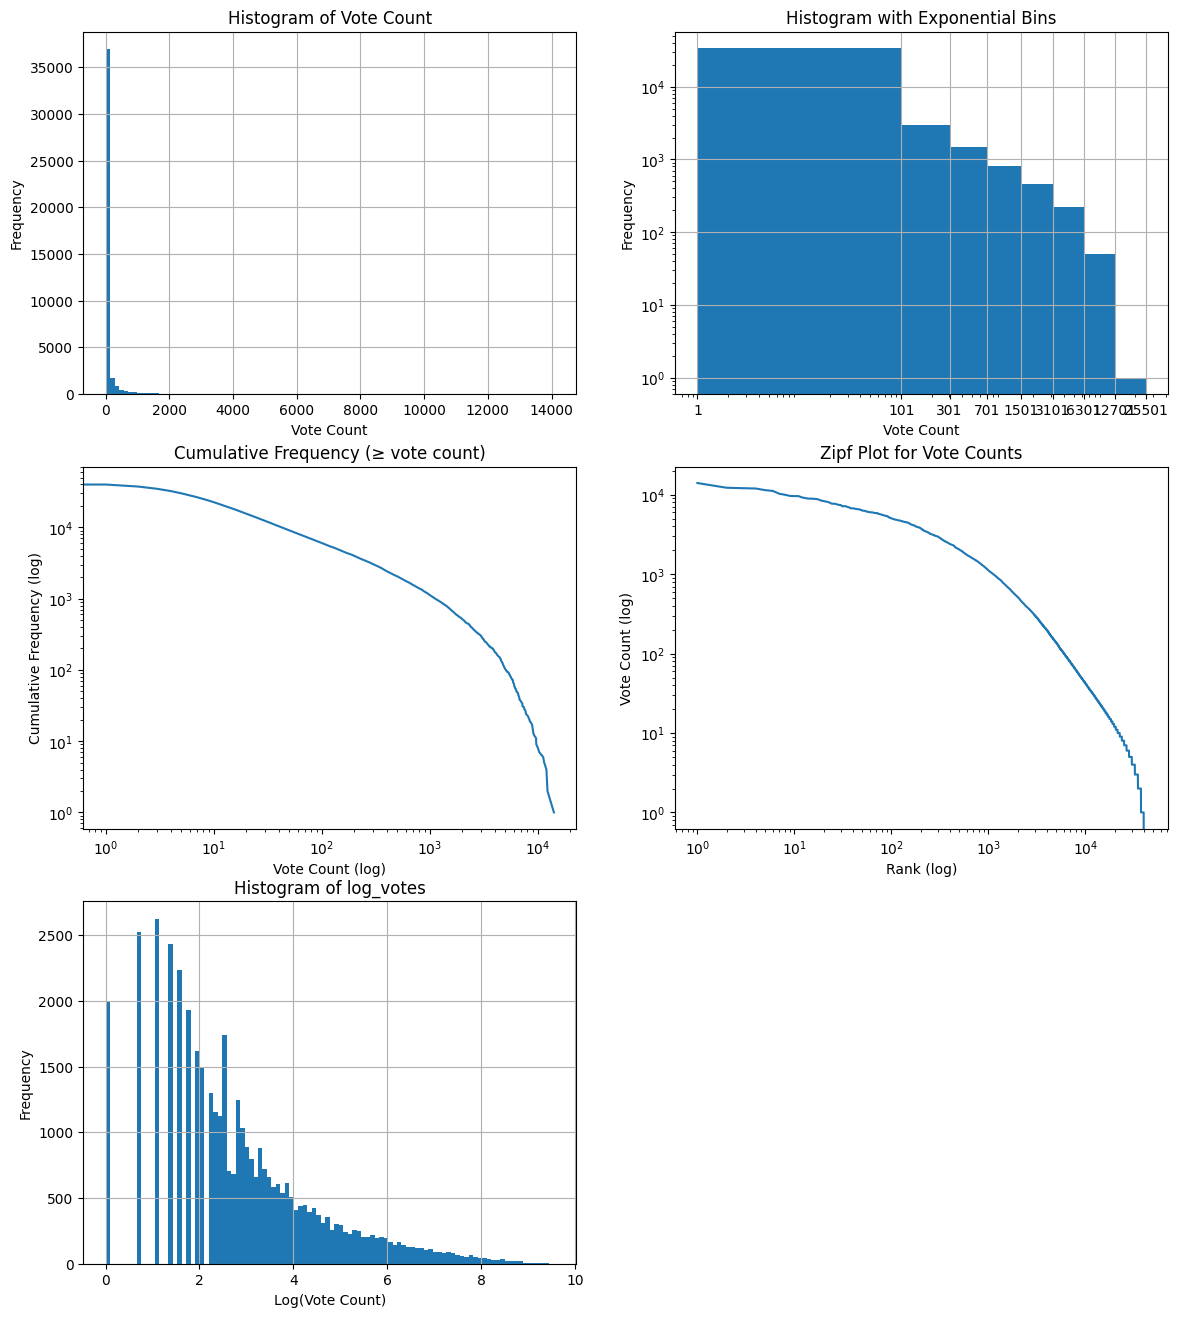

In [17]:
import matplotlib.pyplot as plt  #ploting for python
import numpy as np   #import numpy

fig, axes = plt.subplots(3, 2, figsize=(14, 16))   #making the whole figure


# 2.1

df['vote_count'].hist(bins=100, ax=axes[0, 0])

axes[0, 0].set_xlabel('Vote Count')  #x-axis label
axes[0, 0].set_ylabel('Frequency')  #y-axis label
axes[0, 0].set_title('Histogram of Vote Count')   #x-title


# 2.2

bins = [1]     #start-point
width = 100
while bins[-1] < df['vote_count'].max():
    next_edge = bins[-1] + width
    bins.append(next_edge)
    width *= 2

df['vote_count'].hist(bins=bins, ax=axes[0, 1])

axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xticks(bins)
axes[0, 1].set_xticklabels(bins)
axes[0, 1].set_xlabel('Vote Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram with Exponential Bins')


# 2.3 Cumulative Frequency Vector


freq = df.groupby('vote_count').size().sort_index()
#antisrefei to freq kai meta ypologizei to sum kai tin jana-epanaferei opws sti arxi

cum = [0] * len(freq)
cum[-1] = freq.iloc[-1]

for i in range(len(freq)-2, -1, -1):
    cum[i] = cum[i+1] + freq.iloc[i]

cumfreq = pd.Series(cum, index=freq.index)

axes[1, 0].plot(cumfreq.index, cumfreq.values)  #kanei plot to arithmo vote_count kai ti athroistiki ikanotia apo to cumsum dhladh (P(vote_count>=X))
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel("Vote Count (log)")
axes[1, 0].set_ylabel("Cumulative Frequency (log)")
axes[1, 0].set_title("Cumulative Frequency (≥ vote count)")


# 2.4 Zipf plot

vc_sorted = df['vote_count'].sort_values(ascending=False).reset_index(drop=True)  #sorted from biggest to min and reset the index 0,1,2,3
ranks = vc_sorted.index + 1  #ranking by the index

axes[1, 1].plot(ranks, vc_sorted)
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel("Rank (log)")
axes[1, 1].set_ylabel("Vote Count (log)")
axes[1, 1].set_title("Zipf Plot for Vote Counts")



# 2.5 Histogram of log_votes

df['log_votes'] = np.log(df['vote_count'] + 1)   #log(x+1)=logx
df['log_votes'].hist(bins=100, ax=axes[2, 0])

axes[2, 0].set_xlabel('Log(Vote Count)')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title('Histogram of log_votes')


axes[2, 1].axis('off')


plt.show()


###Αποτελέσματα για το βήμα 2
---

Απο την αναλυση των διαγραμματων παρατηρουμε οτι η κατανομη των ψηφων (vote_count) δεν ακολουθει την Κανονικη Κατανομη αλλα προσεγγιζει μια κατανομη Νομου της Δυναμης (Power-Law) η αλλιως κατανομη Μακρας Ουρας (Long Tail).

Συγκεκριμενα τα δεδομενα παρουσιαζουν εντονη δεξια ασυμμετρια: η συντριπτικη πλειοψηφια των ταινιων συγκεντρωνει πολυ μικρο αριθμο ψηφων, ενω ελαχιστες ταινιες (οι πολυ δημοφιλεις) εχουν εξαιρετικα υψηλο αριθμο ψηφων. Αυτο ηταν αναμενομενο καθως οι γνωστες ταινιες προσελκυουν εκθετικα περισσοτερο ενδιαφερον σε σχεση με τις πιο αγνωστες.

Η συμπεριφορα αυτη επιβεβαιωνεται απο τα σχηματα: Στο ιστογραμμα με εκθετικο binning (log-log scale) καθως και στο Zipf plot, παρατηρειται μια σχεδον γραμμικη πτωση. Η εμφανιση ευθειας γραμμης σε αυτη την κλιμακα αποτελει τη χαρακτηριστικη υπογραφη των κατανομων Power-Law. Επισης, στο Cumulative Frequency plot η καμπυλη μειωνεται ομαλα, επιβεβαιωνοντας τη σπανιοτητα των ταινιων με πολλες ψηφους.

Τελος, στο ερωτημα 2.5 οπου μετασχηματιζουμε τα δεδομενα σε λογαριθμικη κλιμακα (log_votes), παρατηρουμε οτι η κατανομη διορθωνεται και προσεγγιζει πλεον την Κανονικη Κατανομη (Bell Curve). Αυτο αποτελει ισχυρη ενδειξη οτι τα αρχικα δεδομενα ακολουθουν Λογαριθμικη-Κανονικη (Log-Normal) κατανομη. Τα κενα που εμφανιζονται στο αριστερο μερος οφειλονται στη διακριτη φυση των τιμων για ταινιες με ελαχιστες ψηφους.


### Βήμα 3

---




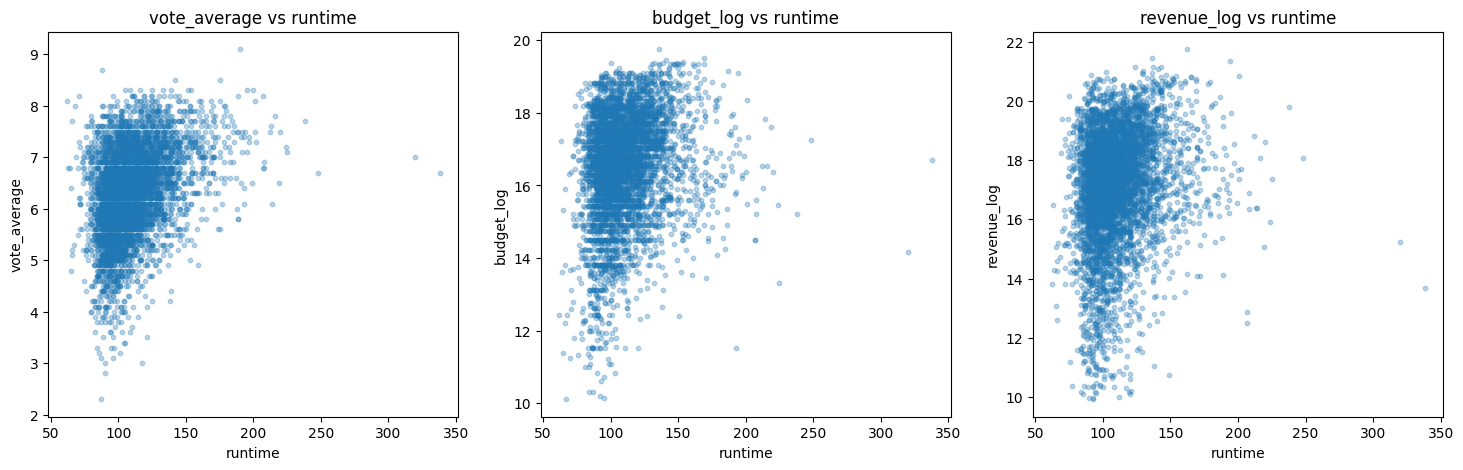

vote_average vs runtime: r = 0.3576, p-value = 1.9285e-150
budget_log vs runtime: r = 0.1956, p-value = 3.2263e-44
revenue_log vs runtime: r = 0.1894, p-value = 1.5018e-41


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


df_filtered = df[
    (df['runtime'] > 30) &
    (df['vote_count'] > 10) &
    (df['budget'] > 20000) &
    (df['revenue'] > 20000)
].copy()


df_filtered['budget_log'] = np.log(df_filtered['budget']+ 1)  #xrisi log gia ta polli megala dedomena ,normalize
df_filtered['revenue_log'] = np.log(df_filtered['revenue']+1)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_pairs = [('runtime', 'vote_average'),
                 ('runtime', 'budget_log'),
                 ('runtime', 'revenue_log')]

for i, (x, y) in enumerate(scatter_pairs):
    axes[i].scatter(df_filtered[x], df_filtered[y], alpha=0.3, s=10)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f"{y} vs {x}")



plt.show()

#ypolizei to r kai to p-value gia toys sindiasmoys twn grafimatwn
for x, y in scatter_pairs:
    r, p = pearsonr(df_filtered[x], df_filtered[y])
    print(f"{y} vs {x}: r = {r:.4f}, p-value = {p:.4e}")


###Αποτελέσματα για το βήμα 3
---
Παρατηρουμε οτι μετα απο την επεξεργασια των δεδομενων και κρατωντας οσα χρειαζομαστε σε ενα πινακα df_filtered ,μετατρεπουμε τα δεδομενα του budget ,revenue σε λογαριθμικη κλιμακα επειδη εχουμε τεραστιες διαφορες στα δεδομενα πχ καποιο μπορει ειναι 20.000 και καποιο 10.000.000.

Για το διαγραμμα του **vote_average--runtime** βλεπουμε οτι το r=0.3576 ειναι πολυ κοντα προς το μηδεν αλλα φαινεται μια ελαφρια θετικη συσχετιση απο κατω αριστερα προς τα δεξια και εχουμε το p-value= 1.9285e-150< << 0.05 οποτε αυτο καταλαβαινουμε οτι δε ειναι στατιστικα τυχαια αλλα πολυ σημαντικη συσχδτιση αφου οσο μεγαλυτερο runtime τοσο καλυτεορ vote_average.Συμφωνα με αυτα τα δεδομενα οι ταινιες με μεγαλυτερο runtime τεινουν να ειναι περισσοτερο δημοφιλεις και οχι λιγοτερο.

Για το διαγραμμα του **budget--runtime** βλεπουμε οτι το r=0.1956 ποθ δηλωνει μια πιο ασθενης συσχετιση με το νεφος να πηγαινει απο κατω αριστερα προς τα πανω δεξια αλλα με το p-value< < 0.05 δεινχει οτι ειναι στατιστικα σημαντικη και οχι τυχαια.Με μια αρχικη υποθεση οτι για μεγαλυτερο runtime εχουμε υψηλοτερο budget τοτε το διαγραμμα αληθευει και φαινεται οτι ταινιες με μεγαλυτερη διαρκεια εχουν μεγαλυτερο budget.

Για το διαγραμμα **revenue--runtime** παρατηρουμε οτι για r=0.1894 εχουμε πιο ασθενης συσχετισγη απο κατω αριστερα προς τα πσνω αριστερα και λιγοτερα δεξια.Με το p-value παλι πολυ μικροτερο του 0.05 η υποθεση ειναι στατιστικα σημαντικη και οχι τυχαια η συσχετιση.Με βαση την αρχικη υποθεση οτι η οποια ελεγε μικροτερο revenue αυτο διαψευεται αφου εχουμε στα δεδομενα οτι ταινιες με μεγαλυτερο runtime τεινουν να εχουν ελαφρως μεγαλυτερο revenue.

### Βήμα 4

---




/tmp/ipython-input-506831175.py:21: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df_vima3 = df[condition_decade & condition_vote]  #sinthikes gia ta data


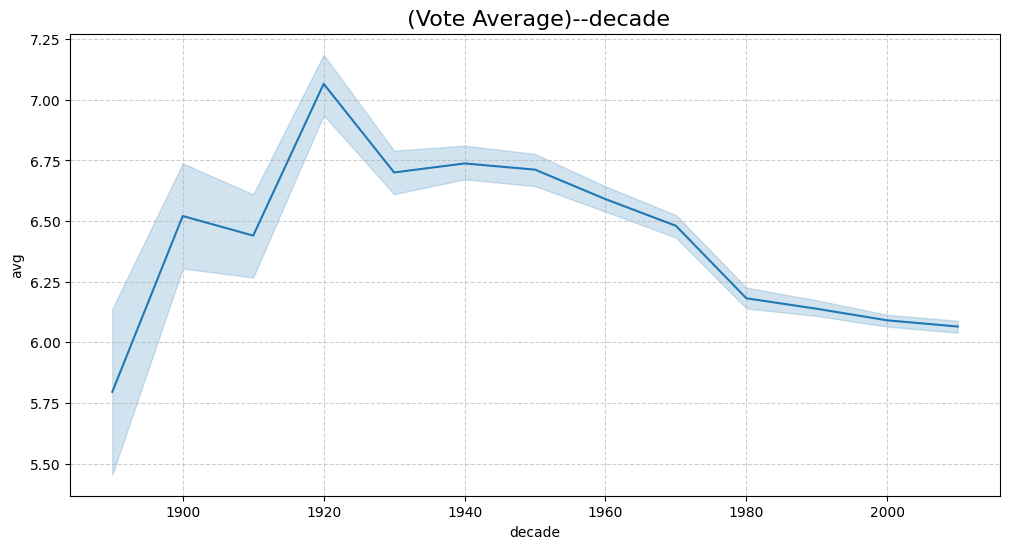

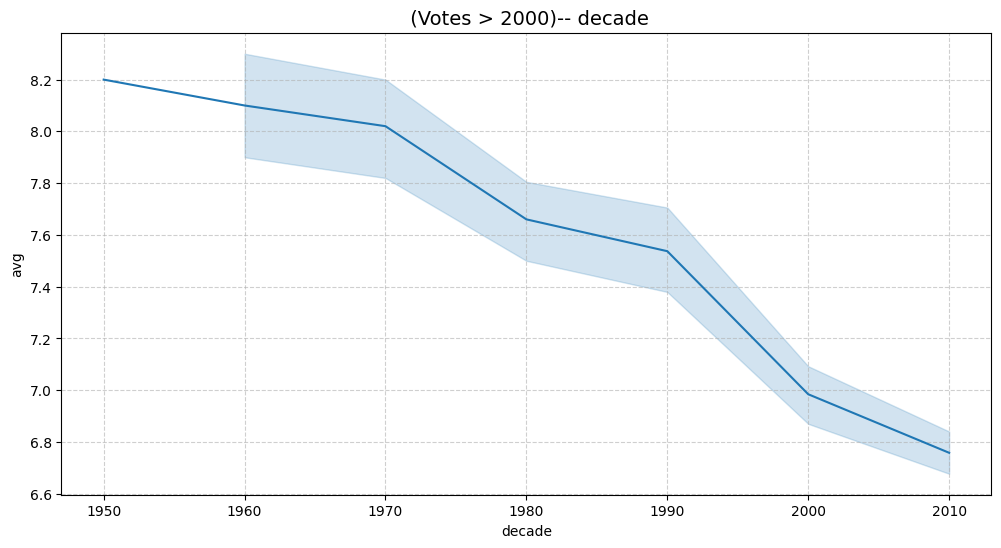

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt


df['year'] = df['release_date'].dt.year    ##kratame to year mono
df['decade'] = (df['year'] // 10) * 10   #kathe year to kanoyme decade
decade_counts = df.groupby('decade').size()    #groupby gia kathe decade, gia synoliko size


filtered_decades = decade_counts[decade_counts > 50]   #krata ta decades  opy >50 tainies

popular_decades_list = filtered_decades.index  #lista me to index twn stoixeiwn


condition_decade = [x in popular_decades_list for x in df['decade']]  #an ta synolika decade einai mesa sto popul krata ayta


condition_vote = df['vote_count'] > 10


df_vima3 = df[condition_decade & condition_vote]  #sinthikes gia ta data

plt.figure(figsize=(12, 6))

sns.lineplot(x='decade', y='vote_average', data=df_vima3)

plt.title(' (Vote Average)--decade', fontsize=16)
plt.xlabel('decade')
plt.ylabel('avg')
plt.grid(True, linestyle='--', alpha=0.6)


plt.show()


#--------------------bonus---------------------------------------------

Pop = 2000

df_fair_comparison = df_vima3[df_vima3['vote_count'] > Pop]  #kratame mono gia vote_count>popular_vote

plt.figure(figsize=(12, 6))


sns.lineplot(x='decade',y='vote_average',data=df_fair_comparison,errorbar=('ci', 95))


plt.title(f' (Votes > {Pop})-- decade', fontsize=14)
plt.xlabel('decade')
plt.ylabel('avg')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()




###Αποτελεσματα βημα 4
---
Παρατηρουμε μεσω των γραφικων παραστασεων οτι για τις παλαιοτερες ταινιες, οι οποιες ειναι και λιγοτερες, προκυπτει οτι φαινεται πιο δημοφιλεις σε συγκριση με τις νεοτερες (π.χ. δεκαετια 1990 και μετα). Αυτό οφειλεται στο γεγονος οτι στις νεοτερες δεκαετιες υπαρχει μεγαλυτερος αριθμος ταινιων με ποικιλο αριθμο ψηφων, περιλαμβανομενων και λιγοτερο δημοφιλων ταινιων.

Οταν ομως θεσουμε ενα περιορισμο vote_count > 2000, ωστε να κρατησουμε μονο ταινιες με σημαντικο αριθμο ψηφων ανα δεκαετια, παρατηρουμε οτι ο μεσος ορος του vote_average είναι υψηλοτερος για τις λιγες παλαιες ταινιες και, γενικοτερα, για καθε δεκαετια που πληροι τη συνθηκη, ο μεσος ορος αυξανεται σε σχεση με το αρχικο συνολο.


###Βημα 5

---



                 Female   Male
genres_list                   
Action               82   4255
Adventure            55   2343
Animation            36    890
Comedy              530   7777
Crime                76   2881
Documentary         214   1283
Drama               956  12083
Family              107   1710
Fantasy              54   1430
Foreign              53    734
History              43    876
Horror               80   2821
Music                55    993
Mystery              58   1641
Romance             409   4194
Science Fiction      40   1947
TV Movie             33    525
Thriller            164   4864
War                  26    848
Western               9    731
Chi2: 855.6377263893731, P-value: 3.1507902649695194e-169


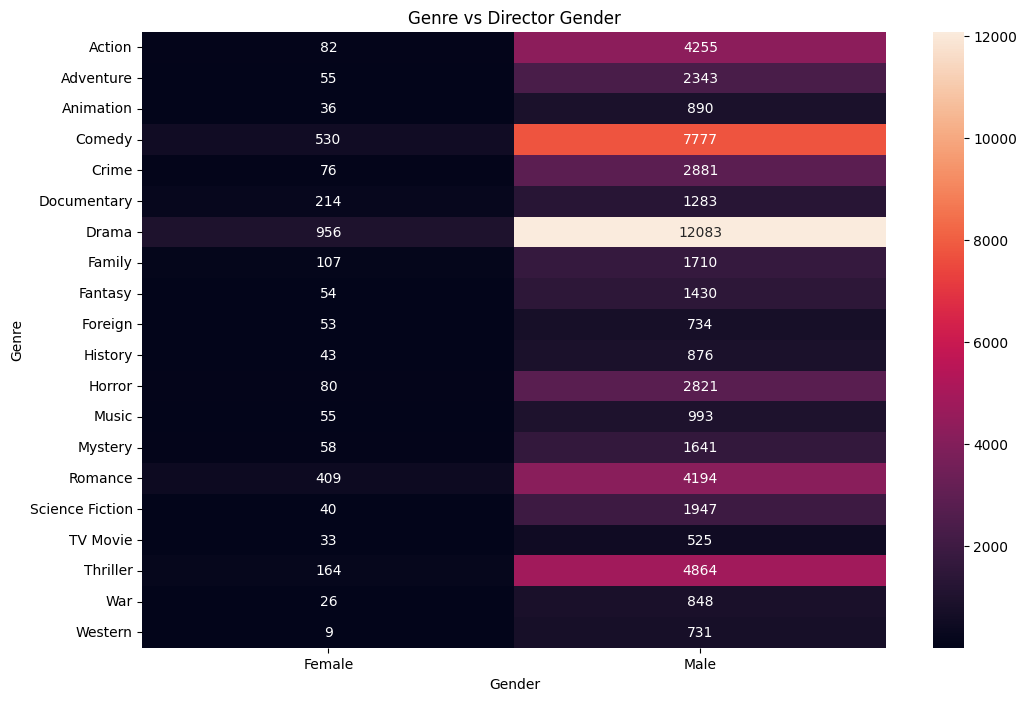

In [36]:

import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df_credits = pd.read_csv("credits.csv")  #read to arxeio credits.csv

df['genres_list'] = df['genres'].apply(
    lambda x: [i['name'] for i in ast.literal_eval(x)] if isinstance(x, str) else []
)
df_genres = df[['id', 'genres_list']].explode('genres_list')   #pairnoyme apo to generes to kathe genre kai meta me vasi to id tis tainia ginetai orizontia


genre_sizes = df_genres.groupby('genres_list').size()
valid_genres = genre_sizes[genre_sizes > 100].index
df_genres = df_genres[df_genres['genres_list'].isin(valid_genres)]   #kane groupb by gia akthe eidos kai krata mono oses to athroimsa einai >100


#synartisi poy pairei mono osi eijai director to onoma kai to gender
def get_gender(x):
    if x is None:
        return 0

    if isinstance(x, str):
        s = x.strip()
        if not (s.startswith('[') and s.endswith(']')):
            return 0
        parsed = ast.literal_eval(s)
    else:
        parsed = x

    if not isinstance(parsed, list):
        return 0

    for item in parsed:
        if isinstance(item, dict) and item.get('job') == 'Director':
            return item.get('gender', 0)

    return 0
#apply ta data apo to arxeiose ayto to df
df_credits['gender'] = df_credits['crew'].apply(get_gender)

df_directors = df_credits[df_credits['gender'].isin([1, 2])][['id', 'gender']]  #kratame mono ta gender twn directors opyo einai sto [1,2]
#merge to movies_metadata me to credits me vasi to id
df_final = df_genres.merge(df_directors, on='id')

#ypologismos toy chi^2 ki toy p-value  kai heatmap gia gender,genres
contingency_table = pd.crosstab(df_final['genres_list'], df_final['gender'])
contingency_table.columns = ['Female', 'Male']
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2: {chi2}, P-value: {p}")

plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d')
plt.title('Genre vs Director Gender')
plt.xlabel('Gender')
plt.ylabel('Genre')
plt.show()




###Aποτελέσματα βήμα 5


---



Τα αποτελεσματα της στατιστικης αναλυσης μεσω του ελεγχου X2 (Chi-Square Test) παρηγαγαν μια τιμη στατιστικης σημαντικοτητας (p-value) πρακτικα ιση με μηδεν (3.150 x 10^-169), η οποια ειναι πολυ μικροτερη απο το οριο του 0.05. Αυτο το ευρημα μας οδηγει στην απορριψη της μηδενικης υποθεσης και επιβεβαιωνει οτι υπαρχει ισχυρη και στατιστικα σημαντικη εξαρτηση μεταξυ του ειδους της ταινιας (Genre) και του φυλου του σκηνοθετη.
Εξεταζοντας τον πινακα συναφειας και το heatmap,διαπιστωνουμε οτι οι αντρες σκηνοθετες υπερεχουν σε ολα τα ειδη ταινιων κατα ενα μεγαλο ποσοστο και ειδικα σε ειδη του στυλ Action, Adventure, Sci-Fi σε σχεση με την διαφορα οπου παρατηρουμε σε ειδη Romance,Drama,Family υπαρχει αμιγως περισσοτερες γυναικες.
Συμπερασματικα, το φυλο του δημιουργου επηρεαζει, η επηρεαζεται απο, το ειδος της ταινιας που καλειται να σκηνοθετησει.

###Βήμα 6

---



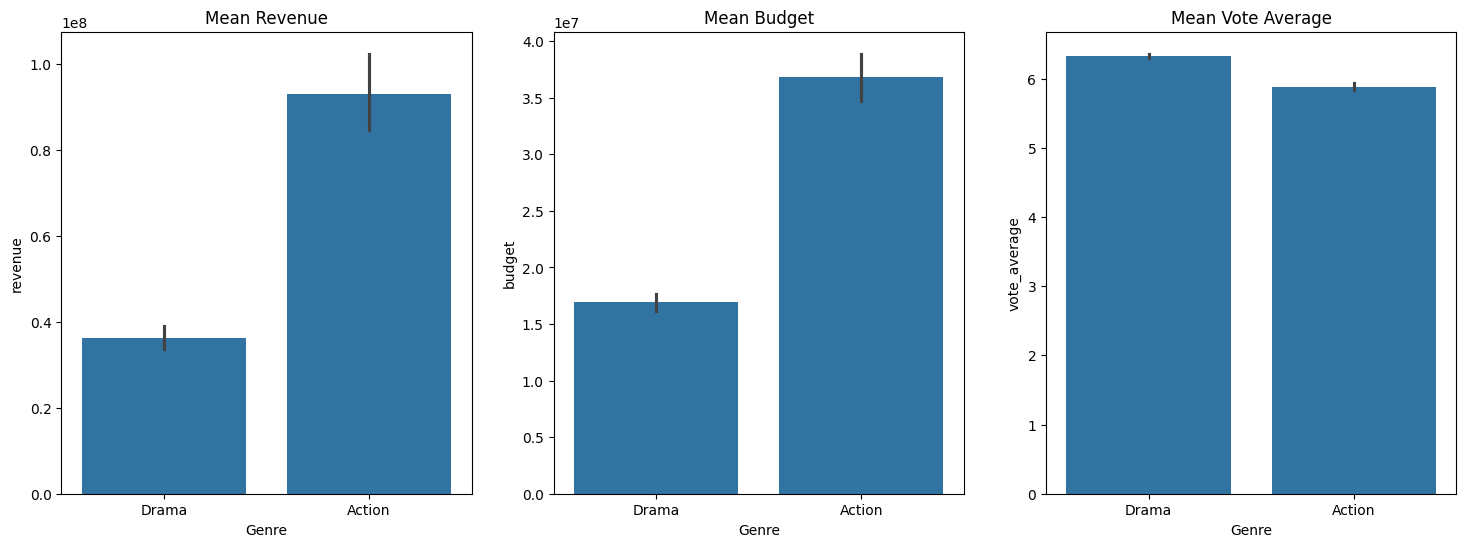


Attribute: REVENUE
Mean Action: 93139999.32
Mean Drama:  36192111.48
P-value: 2.57744e-54

Attribute: BUDGET
Mean Action: 36803340.33
Mean Drama:  16920216.55
P-value: 4.67736e-99

Attribute: VOTE_AVERAGE
Mean Action: 5.89
Mean Drama:  6.33
P-value: 1.57587e-52


In [32]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind




df['genres_list'] = df['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if isinstance(x, str) else [])
df_exploded = df.explode('genres_list')


target_genres = ['Action', 'Drama']
df_compare = df_exploded[df_exploded['genres_list'].isin(target_genres)].copy()

df_compare = df_compare[df_compare['budget'] > 0]



fig, axes = plt.subplots(1, 3, figsize=(18, 6))


attributes = ['revenue', 'budget', 'vote_average']
titles = ['Mean Revenue', 'Mean Budget', 'Mean Vote Average']

for i, col in enumerate(attributes):

    sns.barplot(x='genres_list', y=col, data=df_compare, ax=axes[i],errorbar=('ci', 95))
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Genre')
    axes[i].set_ylabel(col)



plt.show()


for col in attributes:

    action_vals = df_compare[df_compare['genres_list'] == 'Action'][col].dropna()
    drama_vals = df_compare[df_compare['genres_list'] == 'Drama'][col].dropna()


    t_stat, p_val = ttest_ind(action_vals, drama_vals,equal_var=False)

    print(f"\nAttribute: {col.upper()}")
    print(f"Mean Action: {action_vals.mean():.2f}")
    print(f"Mean Drama:  {drama_vals.mean():.2f}")
    print(f"P-value: {p_val:.5e}")



###Αποτελέσματα βήμα 6

---



Απο την αναλυση των t-tests μεταξυ των ειδων Action (Δραση) και Drama (Δραμα) προκυπτουν ξεκαθαρες και στατιστικα σημαντικες διαφορες σε ολα τα χαρακτηριστικα που εξεταστηκαν. Συγκεκριμενα, παρατηρειται μια τεραστια διαφορα στα οικονομικα μεγεθη, καθως οι ταινιες Δρασης ειναι σημαντικα πιο ακριβες στην παραγωγη τους με μεσο προυπολογισμο 36.80 εκατομμυρια, εναντι μολις 16.92 εκατομμυριων για τις Δραματικες. Αντιστοιχα, οι ταινιες Δρασης αποδιδουν πολυ περισσοτερα εσοδα, με μεσο ορο (93.13 εκατομμυρια), σχεδον τριπλασιο απο αυτον των Δραματικων ταινιων (36.19 εκ.). Και στις δυο περιπτωσεις, το p-value ειναι πρακτικα μηδενικο, επιβεβαιωνοντας οτι αυτο το οικονομικο χασμα δεν ειναι τυχαιο αλλα αποτελει δομικο χαρακτηριστικο της βιομηχανιας. Στην αξιολογηση, ομως, η εικονα αντιστρεφεται, καθως οι Δραματικες ταινιες εχουν υψηλοτερη μεση βαθμολογια (6.33) σε σχεση με τις ταινιες Δρασης (5.89), μια διαφορα που επιβεβαιωνεται επισης ως στατιστικα σημαντικη. Συμπερασματικα, υπαρχει ενας σαφης διαχωρισμος στρατηγικης, οπου το ειδος Action ακολουθει το μοντελο του blockbuster με υψηλο ρισκο και υψηλα εσοδα, ενω το Drama στηριζεται σε χαμηλοτερα budget αλλα κερδιζει σε καλλιτεχνικη αξια και εκτιμηση απο το κοινο.

###Βήμα 7

---



In [24]:
df_merged = df_compare.merge(df_final[['id','gender']], on='id')


female_budgets = df_merged[df_merged['gender']==1]['budget'].dropna()
male_budgets = df_merged[df_merged['gender']==2]['budget'].dropna()

#kratame to bufget mono gia to kathe gender


t_stat, p_val = ttest_ind(female_budgets, male_budgets,equal_var=False)

print(f"Mean Female Budget: {female_budgets.mean():,.0f}")
print(f"Mean Male Budget: {male_budgets.mean():,.0f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"One-tailed p-value: {p_val:.5f}")



Mean Female Budget: 22,438,330
Mean Male Budget: 30,381,671
t-statistic: -4.755
One-tailed p-value: 0.00000


###Αποτελέσματα βήμα 7

---



Με τα συγκεκριμενα αποτελεσματα παιρνουμε τιμες απο το t-test για να συγκρινουμε 2 αριθμητικα δεδομενα απο τη αρχικη υποθεση η οποια μας λεει οτι η γυναικες εχουν μικροτερο buget απο τους ανδρες ,βλεπουμε οτι ισχυει αφου οι μεσο οροι προυπολγισμων εχουν μια διαφορα της ταξης των 8.000.000 και με το p-value να μας δειχνει οτι η αποφαση ειναι στατιστικα σημαντικη αλλα και η τιμη του t-test να ειναι αρνητικη δηλωνει οτι στατιστικα ισχυρη και δειχνει mean-women <  mean-man

###Βήμα 8

---



Θα κανω τη συγκεκριμενη υποθεση οτι οι ταινιες με αντρες σκηνοθετες εχουν περισσοτερες ψηφους απο τις ταινιες απο γυναικες σκηνοθετες.

In [34]:

female_votes = df_merged[df_merged['gender']==1]['vote_count']
male_votes   = df_merged[df_merged['gender']==2]['vote_count']

#kratame gia kathe gender toys ekastote psidoys stis tainies gia ta director

mean_female=female_votes.mean()
mean_male=male_votes.mean()

print(f"Mean vote_count fem director: {mean_female:.0f}")
print(f"Mean vote_count man directors: {mean_male:.0f}")


t_stat, p_val_two_tailed = ttest_ind(male_votes, female_votes,equal_var=False)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"Two-tailed p-value: {p_val_two_tailed:.5f}")

Mean vote_count Female directors: 466
Mean vote_count Male directors: 641

t-statistic: 4.170
Two-tailed p-value: 0.00003


###Αποτελέσματα βήμα 8

---



Με βαση τα αποτελεσματα αυτα προκυπτουν οτι οι αντρες εχουν παραπανω μ.ο ψηφων απο τις γυναικες στην ταξη του +175 ψηφοι παραπανω.Μεσω της στατιστικης αναλυσης μεσω της χρησης του t-test το οποιο ειναι θετικο >4.170 παρατηρουμε οτι μεσος των ανδρων > ο μεσος των γυναικων και η διαφορα ειναι στατιστικα σημαντικη.Τωρα για το p-value βλεπουμε οτι ειναι πολυ μικρο οριακα 0 οπου ισχυει οτι p-value< 0.05 τοτε δειχνει οτι η υποθεση που καναμε αρχικα επιβεβαιωνεται.